In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='svg'

from morphing_birds import Hawk3D, animate_plotly_compare
from BirdDMD import run_single_wingbeat_dmd
import matplotlib.pyplot as plt

In [4]:
times, markers, Lambda, Modes, bn, Psi, phase_shifts, keypoints = run_single_wingbeat_dmd(
    bird_name ="Toothless",
    perch_dist="12m",
    turn="Straight",
    behaviour="Initial",
    n_modes=8,
    d=2,
    verbose=True
)



Loading Toothless bilateral data with 12m perch distances, initial.
Dataframe with shape (4060, 38) loaded. Number of sequences: 175
Running DMD for Toothless, 12mm, Straight turn, seqID: 04_12_101
[ 0.+129.778j -0.-129.778j  0. +63.791j -0. -63.791j  0. +31.317j
 -0. -31.317j -0.  -0.j    -0.  -0.j   ]


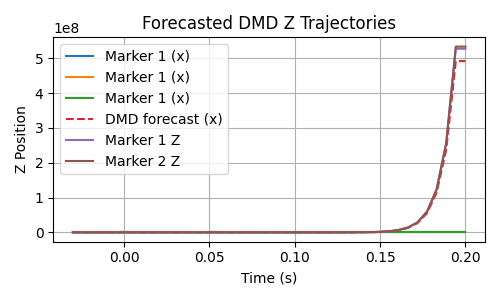

In [24]:
plt.plot(times, keypoints[:, 0, 2], label='Marker 1 Z')
plt.plot(times, keypoints[:, 1, 2], label='Marker 2 Z')
plt.xlabel("Time (s)")
plt.ylabel("Z Position")
plt.title("Forecasted DMD Z Trajectories")
plt.legend()
plt.grid(True)
plt.show()

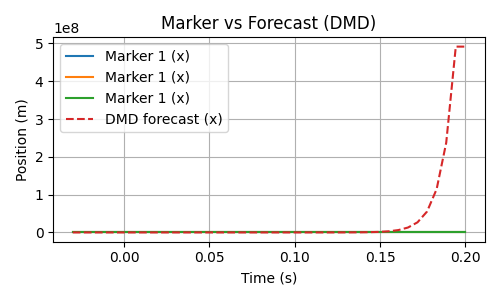

In [25]:

# 📊 Plot example marker trace
plt.figure(figsize=(5, 3))
plt.plot(times, markers[:, 0], label="Marker 1 (x)")
plt.plot(times, keypoints[:, 0, 0], label="DMD forecast (x)", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Marker vs Forecast (DMD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
original_markers = markers.reshape(-1, 8, 3)
hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
animate_plotly_compare(hawk3d, keypoints_frames_list=[original_markers, keypoints], colours=["blue", "red"])